# Phase 9-1: 최신 아키텍처 이해 (MoE, Mamba, Long Context)

> Transformer는 정답이 아니라 현재의 최선이다 -- 최선은 언제든 교체된다

---

## 학습 목표

| # | 목표 | 핵심 질문 |
|---|------|----------|
| 1 | **MoE (Mixture of Experts)** 구조와 라우팅 메커니즘 이해 | 왜 모든 파라미터를 매번 활성화하는가? |
| 2 | **Mamba / SSM** 의 선형 복잡도 원리 이해 | Attention이 유일한 방법인가? |
| 3 | **Long Context** 위치 인코딩 확장 기법 비교 | 학습 길이를 넘어서 어떻게 외삽하는가? |
| 4 | 요구사항에 맞는 **아키텍처 선택** 의사결정 | Dense / MoE / Mamba 중 무엇을 선택할 것인가? |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"Phase 9-1: 최신 아키텍처 이해 (MoE, Mamba, Long Context)")
print(f"실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"NumPy: {np.__version__}")

Phase 9-1: 최신 아키텍처 이해 (MoE, Mamba, Long Context)
실행 시각: 2026-03-19 15:21
NumPy: 2.2.6


---
## 1. 왜 Transformer를 넘어서는가

Transformer의 Self-Attention은 시퀀스 길이 n에 대해 **O(n^2)** 복잡도를 가진다.  
이것은 물리적 한계가 아니라 **설계 선택**이다.

| 시퀀스 길이 | Attention 연산량 (O(n^2)) | 메모리 (KV Cache) |
|------------|--------------------------|------------------|
| 2K | 4M | 기본 |
| 8K | 64M (16배) | 4배 |
| 32K | 1B (256배) | 16배 |
| 128K | 16B (4,096배) | 64배 |
| 1M | 1T (250,000배) | 512배 |

시퀀스 길이가 10배 늘면 연산량은 **100배** 폭발한다.  
O(n) 선형 복잡도 대안이 필요한 이유가 여기에 있다.

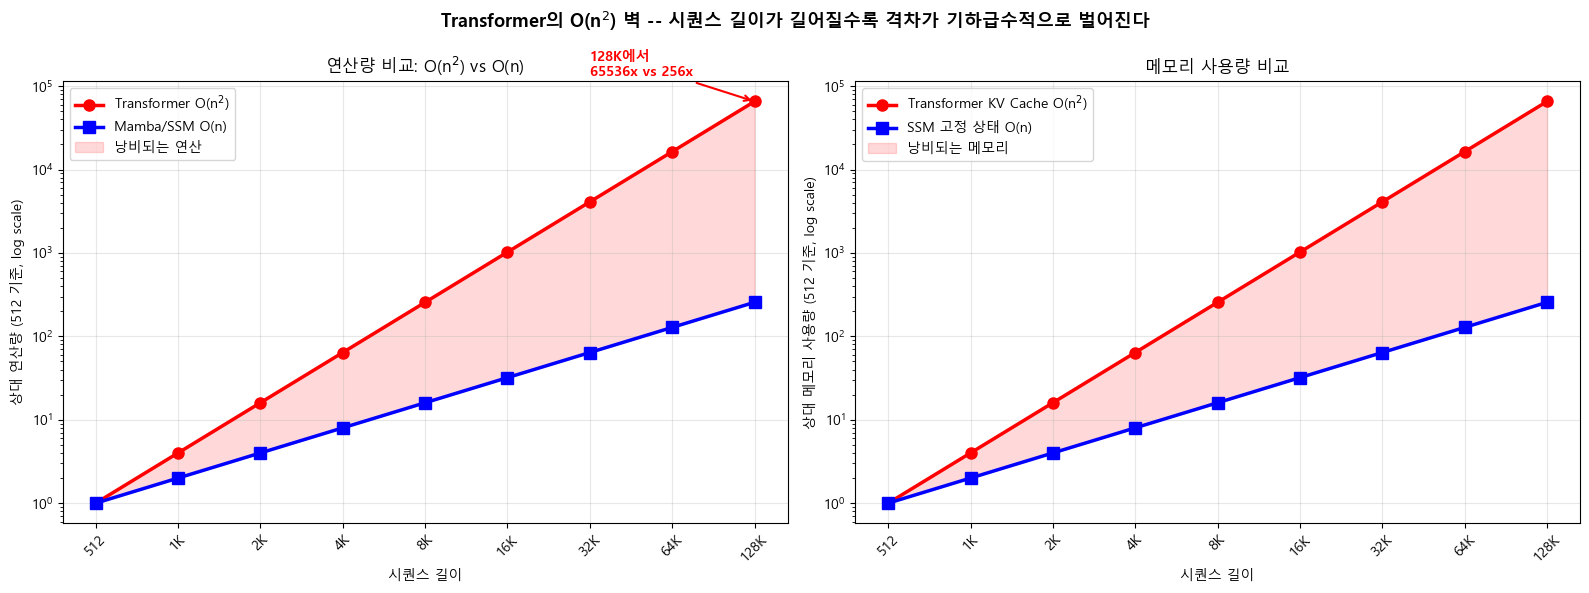


시퀀스 128K 기준:
  Transformer 연산량: 512 대비 65,536배
  Mamba/SSM 연산량:   512 대비 256배
  차이: 256배 -- 이것이 O(n^2)의 대가


In [2]:
# === Transformer O(n^2) vs O(n) 복잡도 시각화 ===

seq_lengths = np.array([512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072])
seq_labels = ['512', '1K', '2K', '4K', '8K', '16K', '32K', '64K', '128K']

# 복잡도 계산 (상대적)
computation_quadratic = (seq_lengths / 512) ** 2   # O(n^2)
computation_linear = seq_lengths / 512              # O(n)
memory_quadratic = (seq_lengths / 512) ** 2         # KV Cache O(n^2)
memory_linear = seq_lengths / 512                   # SSM 고정 상태 O(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: 연산량
axes[0].semilogy(range(len(seq_lengths)), computation_quadratic, 'ro-', linewidth=2.5,
                 markersize=8, label='Transformer O(n$^2$)', zorder=5)
axes[0].semilogy(range(len(seq_lengths)), computation_linear, 'bs-', linewidth=2.5,
                 markersize=8, label='Mamba/SSM O(n)', zorder=5)
axes[0].fill_between(range(len(seq_lengths)), computation_linear, computation_quadratic,
                     alpha=0.15, color='red', label='낭비되는 연산')
axes[0].set_xticks(range(len(seq_lengths)))
axes[0].set_xticklabels(seq_labels, rotation=45)
axes[0].set_xlabel('시퀀스 길이')
axes[0].set_ylabel('상대 연산량 (512 기준, log scale)')
axes[0].set_title('연산량 비교: O(n$^2$) vs O(n)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 128K에서의 차이 주석
axes[0].annotate(f'128K에서\n{int(computation_quadratic[-1])}x vs {int(computation_linear[-1])}x',
                 xy=(8, computation_quadratic[-1]), xytext=(6, computation_quadratic[-1] * 2),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                 fontsize=10, color='red', fontweight='bold')

# Panel 2: 메모리
axes[1].semilogy(range(len(seq_lengths)), memory_quadratic, 'ro-', linewidth=2.5,
                 markersize=8, label='Transformer KV Cache O(n$^2$)', zorder=5)
axes[1].semilogy(range(len(seq_lengths)), memory_linear, 'bs-', linewidth=2.5,
                 markersize=8, label='SSM 고정 상태 O(n)', zorder=5)
axes[1].fill_between(range(len(seq_lengths)), memory_linear, memory_quadratic,
                     alpha=0.15, color='red', label='낭비되는 메모리')
axes[1].set_xticks(range(len(seq_lengths)))
axes[1].set_xticklabels(seq_labels, rotation=45)
axes[1].set_xlabel('시퀀스 길이')
axes[1].set_ylabel('상대 메모리 사용량 (512 기준, log scale)')
axes[1].set_title('메모리 사용량 비교')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Transformer의 O(n$^2$) 벽 -- 시퀀스 길이가 길어질수록 격차가 기하급수적으로 벌어진다',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n시퀀스 128K 기준:")
print(f"  Transformer 연산량: 512 대비 {int(computation_quadratic[-1]):,}배")
print(f"  Mamba/SSM 연산량:   512 대비 {int(computation_linear[-1]):,}배")
print(f"  차이: {int(computation_quadratic[-1] / computation_linear[-1])}배 -- 이것이 O(n^2)의 대가")

---
## 2. MoE (Mixture of Experts)

Dense 모델의 근본적 질문: **모든 파라미터가 매번 필요한가?**

MoE는 입력 토큰마다 **Router(Gating Network)** 가 일부 Expert만 선택적으로 활성화한다.

```
입력 토큰 → Router(Softmax) → Top-K Expert 선택 → 가중 합산 → 출력
                                  (보통 K=2)
```

### MoE 핵심 구성 요소

| 구성 요소 | 역할 | 예시 |
|-----------|------|------|
| **Expert** | 독립적 FFN 레이어 | Mixtral: 8개 Expert |
| **Router (Gate)** | 토큰별 Expert 선택 및 가중치 할당 | Softmax 기반 Top-K |
| **Top-K** | 활성화할 Expert 수 | K=2 (Mixtral 기본) |
| **Load Balancing Loss** | Expert 간 균등 분배 유도 | Auxiliary Loss 추가 |

### 핵심 문제: Load Balancing

Router가 특정 Expert에만 토큰을 몰아주면 나머지 Expert는 학습되지 않는다.  
**Auxiliary Loss**를 추가하여 Expert 간 부하를 분산시킨다.

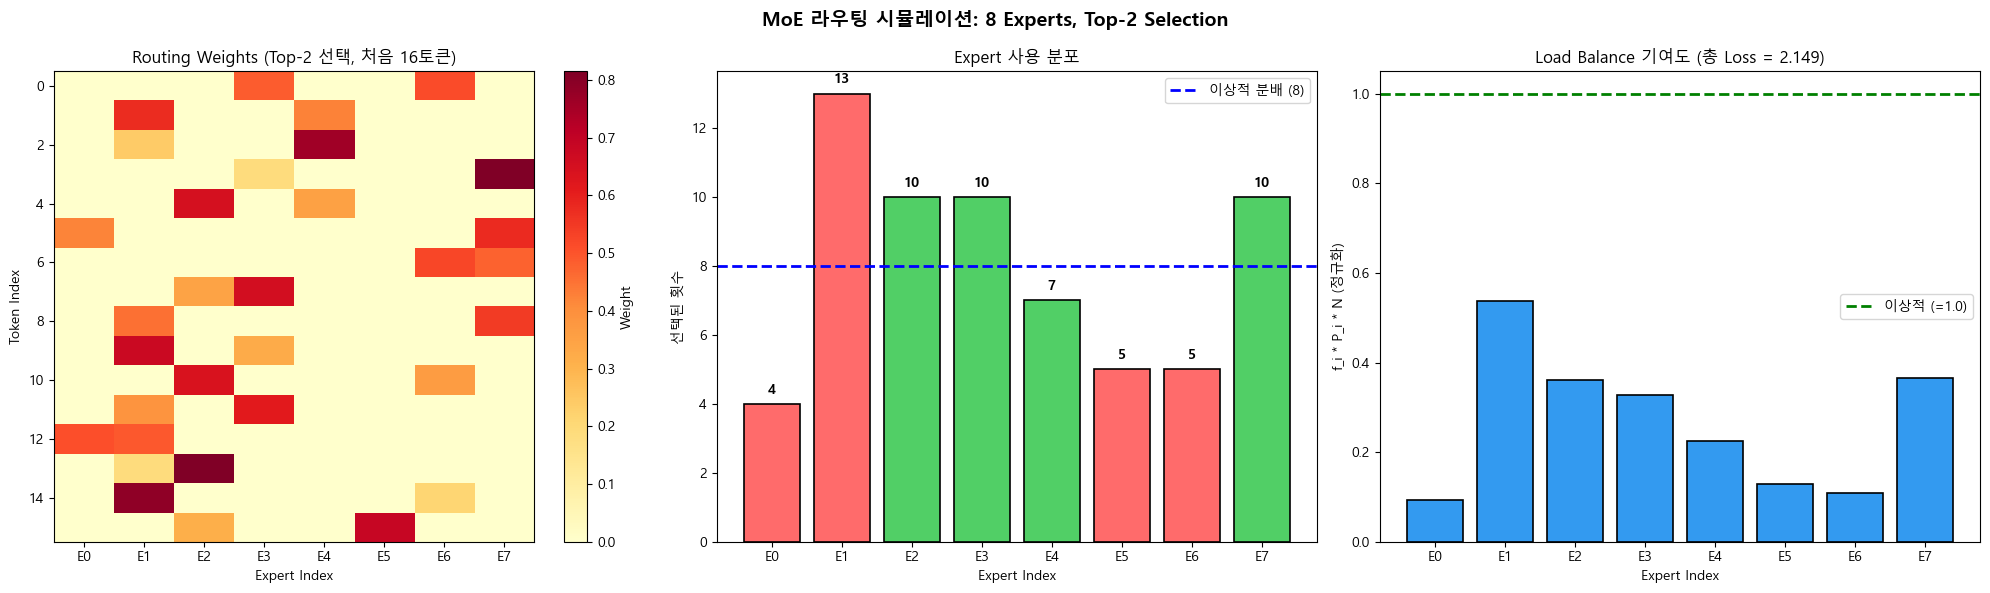

라우팅 통계:
  총 토큰: 32, Top-K: 2
  이상적 Expert당 할당: 8.0회
  실제 분포: [4, 13, 10, 10, 7, 5, 5, 10]
  Load Balance Loss: 2.1485 (이상적 = 1.0)
  불균형 Expert (30% 이상 편차): 4개


In [3]:
# === MoE 라우팅 시뮬레이션 ===

np.random.seed(42)

n_experts = 8
n_tokens = 32
top_k = 2

# Router logits 생성 (각 토큰에 대해 8개 Expert 점수)
router_logits = np.random.randn(n_tokens, n_experts)

# Softmax로 확률 변환
def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

routing_probs = softmax(router_logits)

# Top-K 선택
top_k_indices = np.argsort(routing_probs, axis=-1)[:, -top_k:]  # 상위 2개
top_k_mask = np.zeros_like(routing_probs)
for i in range(n_tokens):
    top_k_mask[i, top_k_indices[i]] = 1

# 선택된 Expert의 가중치만 남기고 re-normalize
selected_weights = routing_probs * top_k_mask
selected_weights = selected_weights / (selected_weights.sum(axis=-1, keepdims=True) + 1e-8)

# Expert별 사용 빈도
expert_usage = top_k_mask.sum(axis=0)  # 각 Expert가 선택된 횟수
ideal_usage = n_tokens * top_k / n_experts  # 균등 분배 시 기대값

# Load Balancing Loss 계산
# L_balance = n_experts * sum(f_i * P_i)
# f_i: Expert i가 선택된 토큰 비율, P_i: Expert i에 대한 평균 라우팅 확률
f = expert_usage / n_tokens  # 선택 비율
P = routing_probs.mean(axis=0)  # 평균 라우팅 확률
load_balance_loss = n_experts * np.sum(f * P)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Routing Weights Heatmap
im = axes[0].imshow(selected_weights[:16], cmap='YlOrRd', aspect='auto')
axes[0].set_xlabel('Expert Index')
axes[0].set_ylabel('Token Index')
axes[0].set_title('Routing Weights (Top-2 선택, 처음 16토큰)')
axes[0].set_xticks(range(n_experts))
axes[0].set_xticklabels([f'E{i}' for i in range(n_experts)])
plt.colorbar(im, ax=axes[0], label='Weight')

# Panel 2: Expert Usage Distribution
colors_usage = ['#ff6b6b' if u > ideal_usage * 1.3 or u < ideal_usage * 0.7
                else '#51cf66' for u in expert_usage]
bars = axes[1].bar(range(n_experts), expert_usage, color=colors_usage, edgecolor='black', linewidth=1.2)
axes[1].axhline(y=ideal_usage, color='blue', linestyle='--', linewidth=2, label=f'이상적 분배 ({ideal_usage:.0f})')
axes[1].set_xlabel('Expert Index')
axes[1].set_ylabel('선택된 횟수')
axes[1].set_title('Expert 사용 분포')
axes[1].set_xticks(range(n_experts))
axes[1].set_xticklabels([f'E{i}' for i in range(n_experts)])
axes[1].legend(fontsize=10)
for i, v in enumerate(expert_usage):
    axes[1].text(i, v + 0.3, f'{int(v)}', ha='center', fontweight='bold')

# Panel 3: Load Balance 분석
balance_scores = f * P * n_experts
axes[2].bar(range(n_experts), balance_scores, color='#339af0', edgecolor='black', linewidth=1.2)
axes[2].axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='이상적 (=1.0)')
axes[2].set_xlabel('Expert Index')
axes[2].set_ylabel('f_i * P_i * N (정규화)')
axes[2].set_title(f'Load Balance 기여도 (총 Loss = {load_balance_loss:.3f})')
axes[2].set_xticks(range(n_experts))
axes[2].set_xticklabels([f'E{i}' for i in range(n_experts)])
axes[2].legend(fontsize=10)

plt.suptitle('MoE 라우팅 시뮬레이션: 8 Experts, Top-2 Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"라우팅 통계:")
print(f"  총 토큰: {n_tokens}, Top-K: {top_k}")
print(f"  이상적 Expert당 할당: {ideal_usage:.1f}회")
print(f"  실제 분포: {expert_usage.astype(int).tolist()}")
print(f"  Load Balance Loss: {load_balance_loss:.4f} (이상적 = 1.0)")
print(f"  불균형 Expert (30% 이상 편차): {sum(1 for u in expert_usage if u > ideal_usage*1.3 or u < ideal_usage*0.7)}개")

---
## 3. MoE의 장단점과 효율성

### 장점 vs 단점

| 장점 | 단점 |
|------|------|
| 파라미터 대비 연산 효율 극대화 | 전체 파라미터를 메모리에 로드해야 함 |
| 모델 용량(지식) 증가 | Load Balancing 설계 필요 |
| 추론 비용은 Dense 모델 수준 | Expert 간 통신 오버헤드 (분산 학습) |
| 특정 도메인 전문화 가능 | Router 학습 불안정성 |

### Mixtral 8x7B 효율성 계산

```
전체 파라미터: 46.7B (8개 Expert x 약 5.8B)
활성 파라미터: 12.9B (Top-2 Expert만 활성)
효율 비율:     12.9B / 46.7B = 27.6%
성능 비교:     70B Dense 모델급 성능을 12.9B 연산으로 달성
효율 배수:     70B / 12.9B = 약 5.4x
```

결론: **모든 뉴런이 매번 필요한가?** MoE는 이 질문에 "아니오"라고 답한다.

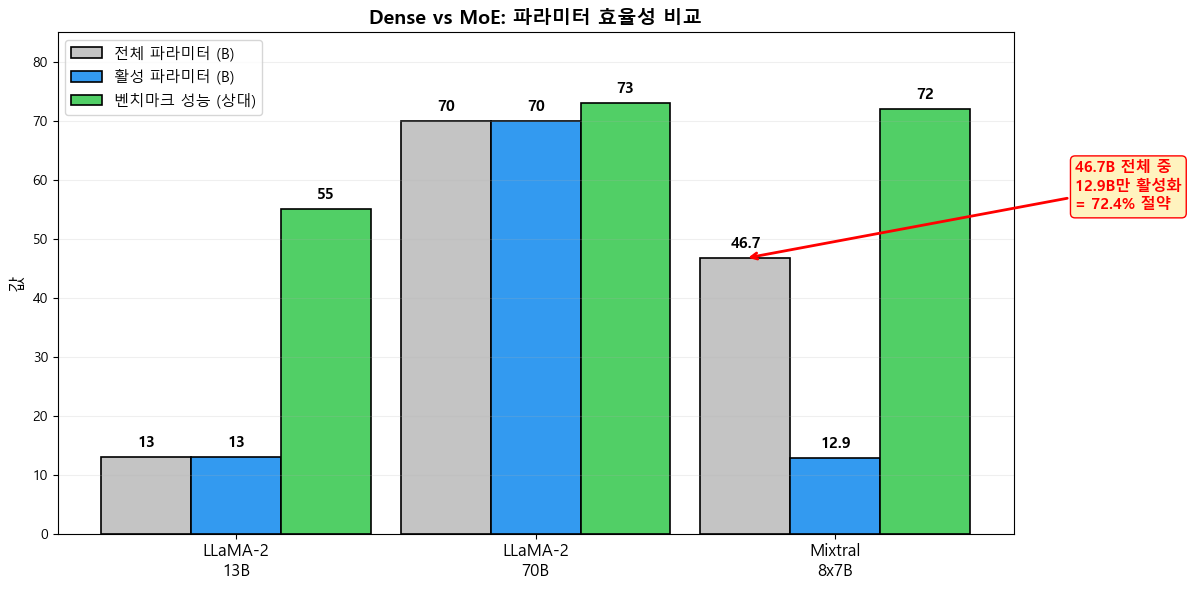

핵심 수치:
  Mixtral 8x7B: 전체 46.7B, 활성 12.9B
  활성 비율: 27.6% (= Top-2/8)
  LLaMA-2 70B 대비: 18.4% 연산으로 유사 성능
  연산 효율: 5.4x 절약


In [4]:
# === MoE 효율성 시각화: Dense vs MoE ===

fig, ax = plt.subplots(figsize=(12, 6))

models = ['LLaMA-2\n13B', 'LLaMA-2\n70B', 'Mixtral\n8x7B']
total_params = [13, 70, 46.7]         # 전체 파라미터 (B)
active_params = [13, 70, 12.9]        # 활성 파라미터 (B)
performance = [55, 73, 72]            # 벤치마크 상대 점수 (가상)

x = np.arange(len(models))
width = 0.3

bars1 = ax.bar(x - width, total_params, width, label='전체 파라미터 (B)',
               color='#c4c4c4', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x, active_params, width, label='활성 파라미터 (B)',
               color='#339af0', edgecolor='black', linewidth=1.2)
bars3 = ax.bar(x + width, performance, width, label='벤치마크 성능 (상대)',
               color='#51cf66', edgecolor='black', linewidth=1.2)

# 값 표시
for bars, vals in [(bars1, total_params), (bars2, active_params), (bars3, performance)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Mixtral 효율성 강조
ax.annotate('46.7B 전체 중\n12.9B만 활성화\n= 72.4% 절약',
            xy=(2 - width, 46.7), xytext=(2.8, 55),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3bf', edgecolor='red'))

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('값', fontsize=12)
ax.set_title('Dense vs MoE: 파라미터 효율성 비교', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.2, axis='y')
ax.set_ylim(0, 85)

plt.tight_layout()
plt.show()

print("핵심 수치:")
print(f"  Mixtral 8x7B: 전체 {total_params[2]}B, 활성 {active_params[2]}B")
print(f"  활성 비율: {active_params[2]/total_params[2]*100:.1f}% (= Top-2/8)")
print(f"  LLaMA-2 70B 대비: {active_params[2]/active_params[1]*100:.1f}% 연산으로 유사 성능")
print(f"  연산 효율: {active_params[1]/active_params[2]:.1f}x 절약")

---
## 4. Mamba / State Space Models (SSM)

MoE는 Transformer **내부**의 효율을 높였다. Mamba는 Transformer의 Attention **자체**를 대체한다.

### 핵심 아이디어

기존 SSM은 입력과 무관한 **고정 파라미터**를 사용했다.  
Mamba는 **Selective SSM**으로, 입력에 따라 파라미터(B, C, Delta)를 동적으로 결정한다.

```
상태 업데이트: h_t = A * h_{t-1} + B * x_t    (재귀적)
출력:         y_t = C * h_t

- A: 상태 전이 행렬 (어떤 정보를 유지할지)
- B: 입력 의존적 (어떤 입력을 기억할지) ← Selective!
- C: 출력 의존적 (어떤 정보를 출력할지) ← Selective!
- Delta: 이산화 스텝 (기억 vs 망각 속도) ← Selective!
```

### Transformer vs Mamba 비교

| 항목 | Transformer | Mamba / SSM |
|------|------------|-------------|
| Attention 복잡도 | O(n^2) | O(n) -- 선형 |
| 추론 시 메모리 | KV Cache 폭발 | 고정 상태 크기 |
| 학습 병렬화 | 우수 (행렬 연산) | 보통 (순차 의존성) |
| Long Context | KV Cache 비용 급증 | 상태 크기 고정 |
| 생태계 성숙도 | 최고 | 초기 단계 |
| 대표 모델 | LLaMA, GPT-3 | Mamba, Jamba |

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


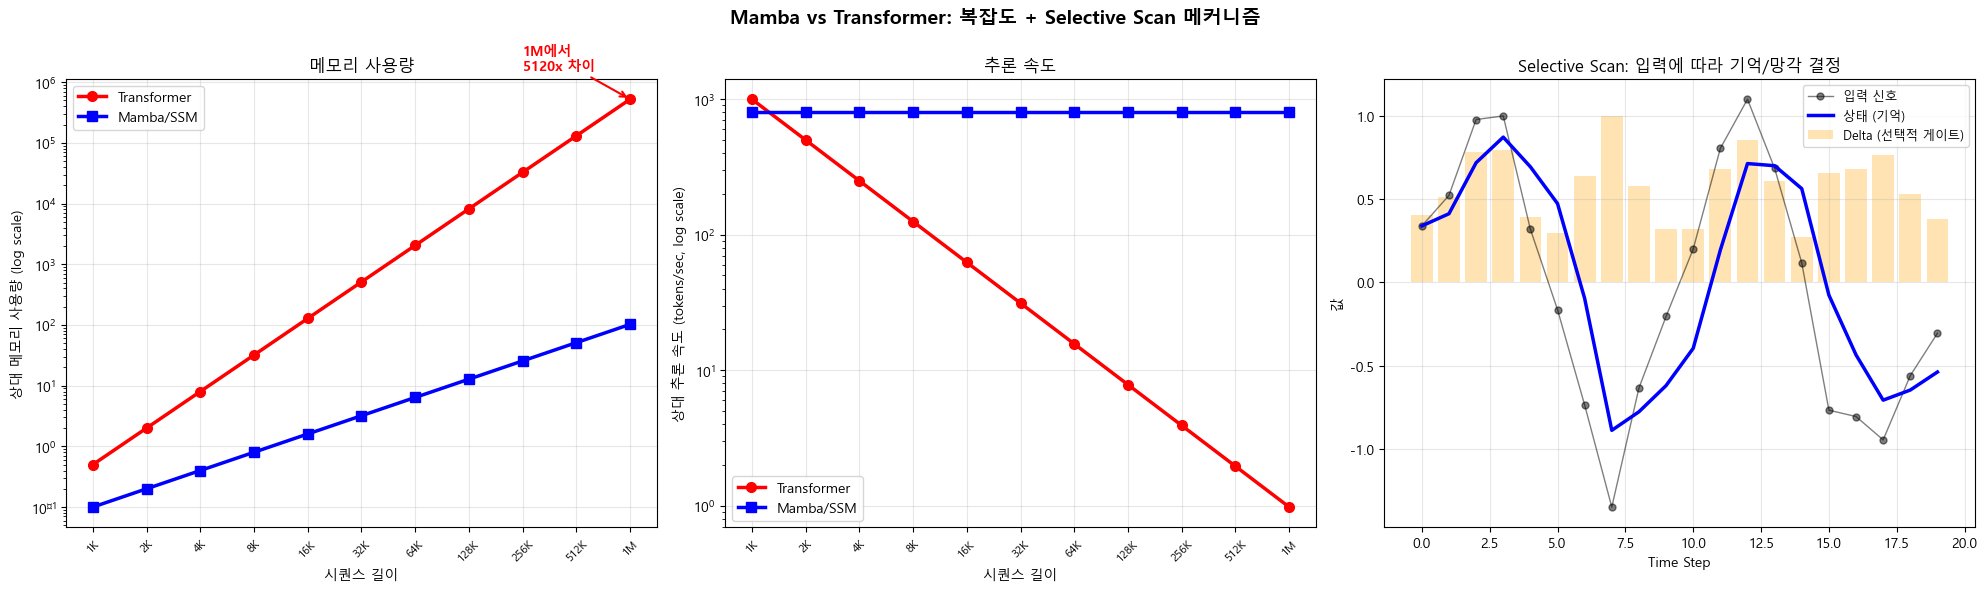

Selective Scan 해석:
  Delta가 클 때 (주황 막대 높음): 현재 입력을 강하게 기억 (이전 상태 잊음)
  Delta가 작을 때: 이전 상태를 유지 (현재 입력 무시)
  -> 입력에 따라 동적으로 기억/망각을 선택 = Selective


In [9]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# === Mamba vs Transformer 복잡도 비교 + Selective Scan 개념 ===

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel 1: 메모리 사용량 (log scale) ---
seq_lengths = np.array([1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576])
seq_labels = ['1K', '2K', '4K', '8K', '16K', '32K', '64K', '128K', '256K', '512K', '1M']

# 메모리 (GB, 대략적 추정)
transformer_memory = (seq_lengths / 1024) ** 2 * 0.5   # O(n^2) KV cache
mamba_memory = seq_lengths / 1024 * 0.1                 # O(n) 고정 상태

axes[0].semilogy(range(len(seq_lengths)), transformer_memory, 'ro-', linewidth=2.5,
                 markersize=7, label='Transformer')
axes[0].semilogy(range(len(seq_lengths)), mamba_memory, 'bs-', linewidth=2.5,
                 markersize=7, label='Mamba/SSM')
axes[0].set_xticks(range(len(seq_lengths)))
axes[0].set_xticklabels(seq_labels, rotation=45, fontsize=8)
axes[0].set_xlabel('시퀀스 길이')
axes[0].set_ylabel('상대 메모리 사용량 (log scale)')
axes[0].set_title('메모리 사용량')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 1M 지점 강조
ratio_memory = transformer_memory[-1] / mamba_memory[-1]
axes[0].annotate(f'1M에서\n{ratio_memory:.0f}x 차이',
                 xy=(10, transformer_memory[-1]), xytext=(8, transformer_memory[-1] * 3),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                 fontsize=10, color='red', fontweight='bold')

# --- Panel 2: 추론 속도 (tokens/sec, log scale) ---
transformer_speed = 1000 / (seq_lengths / 1024)    # 길이 증가 시 감소
mamba_speed = np.full_like(seq_lengths, 800.0, dtype=float)  # 거의 일정

axes[1].semilogy(range(len(seq_lengths)), transformer_speed, 'ro-', linewidth=2.5,
                 markersize=7, label='Transformer')
axes[1].semilogy(range(len(seq_lengths)), mamba_speed, 'bs-', linewidth=2.5,
                 markersize=7, label='Mamba/SSM')
axes[1].set_xticks(range(len(seq_lengths)))
axes[1].set_xticklabels(seq_labels, rotation=45, fontsize=8)
axes[1].set_xlabel('시퀀스 길이')
axes[1].set_ylabel('상대 추론 속도 (tokens/sec, log scale)')
axes[1].set_title('추론 속도')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# --- Panel 3: Selective Scan 개념 ---
np.random.seed(7)
time_steps = 20
input_signal = np.sin(np.linspace(0, 4*np.pi, time_steps)) + np.random.normal(0, 0.2, time_steps)

# Selective: 중요한 입력에 큰 Delta, 덜 중요한 입력에 작은 Delta
importance = np.abs(input_signal)  # 입력 크기 = 중요도 (단순화)
delta = 0.2 + 0.8 * (importance / importance.max())  # Delta: 0.2~1.0

# 상태 업데이트 시뮬레이션
state = np.zeros(time_steps)
state[0] = input_signal[0]
for t in range(1, time_steps):
    forget = np.exp(-delta[t])  # Delta 클수록 더 많이 잊음 (새 입력 수용)
    state[t] = forget * state[t-1] + (1 - forget) * input_signal[t]

axes[2].bar(range(time_steps), delta, alpha=0.3, color='orange', label='Delta (선택적 게이트)')
axes[2].plot(range(time_steps), input_signal, 'ko-', markersize=5, linewidth=1, alpha=0.5, label='입력 신호')
axes[2].plot(range(time_steps), state, 'b-', linewidth=2.5, label='상태 (기억)')
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('값')
axes[2].set_title('Selective Scan: 입력에 따라 기억/망각 결정')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Mamba vs Transformer: 복잡도 + Selective Scan 메커니즘', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Selective Scan 해석:")
print("  Delta가 클 때 (주황 막대 높음): 현재 입력을 강하게 기억 (이전 상태 잊음)")
print("  Delta가 작을 때: 이전 상태를 유지 (현재 입력 무시)")
print("  -> 입력에 따라 동적으로 기억/망각을 선택 = Selective")

---
## 5. Long Context 기법 -- 위치 인코딩 확장

Transformer가 128K, 1M 이상의 긴 문맥을 처리하려면 **위치 인코딩의 확장**이 핵심이다.

### 위치 인코딩 비교

| 항목 | RoPE | YaRN | ALiBi |
|------|------|------|-------|
| **방식** | 회전 행렬로 위치 인코딩 | RoPE + NTK-aware 주파수 보간 | Attention에 거리 기반 선형 편향 |
| **학습 길이 외삽** | 약함 (학습 길이 밖에서 급락) | 강함 (2~8배 확장) | 매우 강함 (이론상 무제한) |
| **구현 위치** | Q, K 벡터에 회전 적용 | Q, K 벡터에 수정된 회전 적용 | Attention Score에 편향 추가 |
| **채택 모델** | LLaMA, Mistral, Qwen | LLaMA 확장 모델들 | BLOOM, MPT |
| **장점** | 상대 위치 인코딩, 효율적 | 학습 없이 컨텍스트 확장 | 구현 간단, 외삽 안정적 |
| **단점** | 외삽 한계 | 극단적 확장 시 품질 저하 | 절대 위치 정보 부재 |

### Long Context의 실전 과제: Lost in the Middle

위치 인코딩을 확장해도 **"Lost in the Middle"** 문제가 존재한다.  
모델은 긴 문맥의 처음과 끝은 잘 기억하지만, 중간 부분의 정보를 놓치는 경향이 있다.  
이를 해결하기 위해 **Ring Attention**, **Sliding Window Attention** 등이 연구되고 있다.

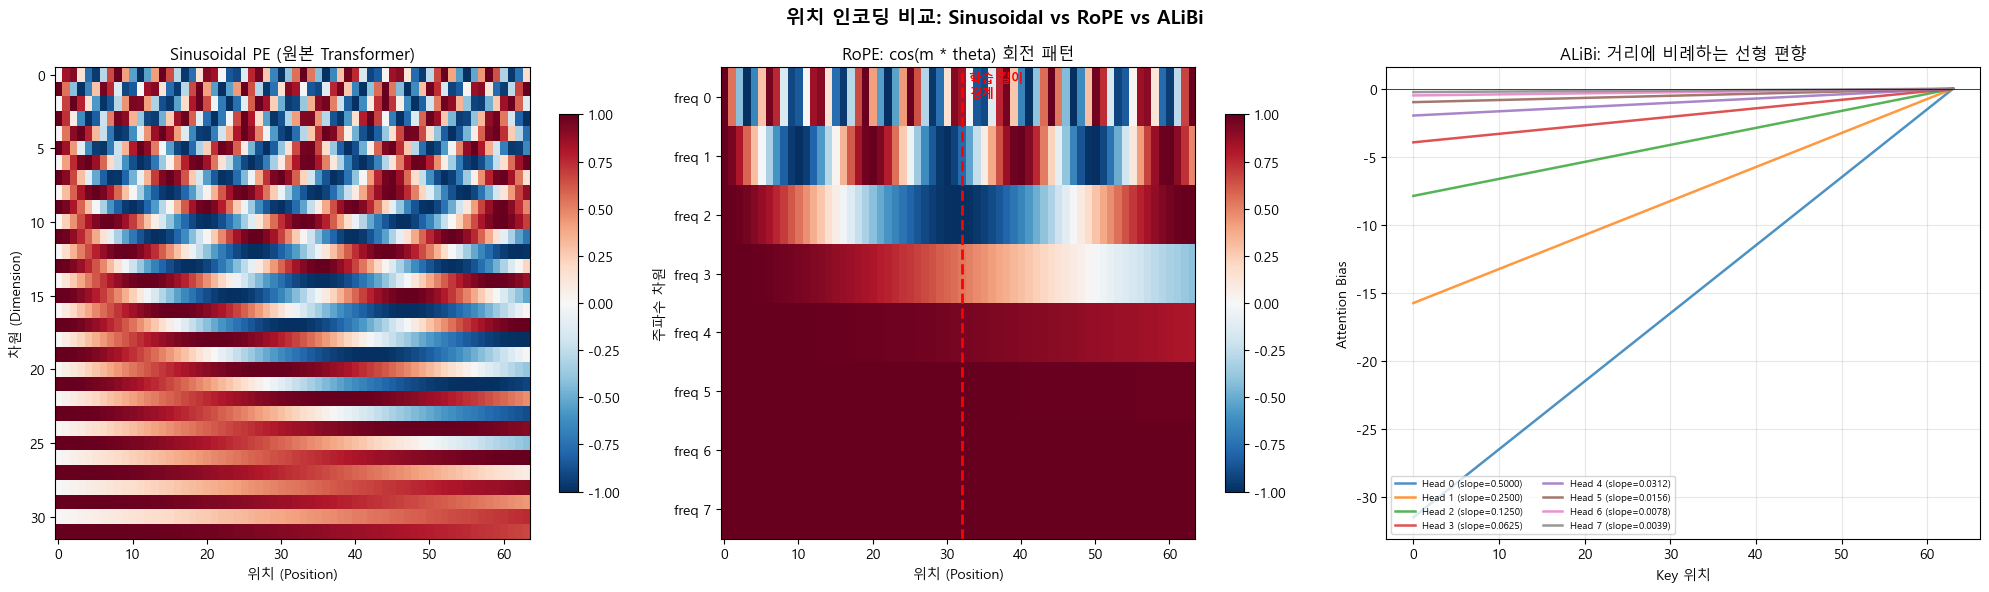

해석:
  Sinusoidal: 절대 위치를 sin/cos 패턴으로 인코딩 (원본 Transformer)
  RoPE: Q, K 벡터를 위치에 비례하는 각도로 회전 -> 상대 위치 자동 인코딩
       빨간 점선 = 학습 길이 경계. 이 너머에서 패턴이 불안정해짐 (외삽 한계)
  ALiBi: Attention score에 -slope * distance 직접 더함
       가까운 토큰 = 높은 점수, 먼 토큰 = 낮은 점수 (자연스러운 감쇠)
       학습 길이와 무관하게 동작 -> 외삽에 강함


In [10]:
# === 위치 인코딩 비교 시각화 ===

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

positions = np.arange(0, 128)
d_model = 64

# --- Panel 1: Sinusoidal Position Encoding ---
pe = np.zeros((len(positions), d_model))
for pos in positions:
    for i in range(0, d_model, 2):
        pe[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
        if i + 1 < d_model:
            pe[pos, i+1] = np.cos(pos / (10000 ** (i / d_model)))

im1 = axes[0].imshow(pe[:64, :32].T, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xlabel('위치 (Position)')
axes[0].set_ylabel('차원 (Dimension)')
axes[0].set_title('Sinusoidal PE (원본 Transformer)')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# --- Panel 2: RoPE - 회전 각도 시각화 ---
# RoPE: 각 차원 쌍에 대해 위치에 비례하는 각도로 회전
n_dims = 8  # 시각화할 차원 쌍 수
freqs = 1.0 / (10000 ** (np.arange(0, n_dims) / n_dims))
positions_rope = np.arange(0, 64)

rotation_angles = np.outer(positions_rope, freqs)  # (pos, dim)

im2 = axes[1].imshow(np.cos(rotation_angles).T, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xlabel('위치 (Position)')
axes[1].set_ylabel('주파수 차원')
axes[1].set_title('RoPE: cos(m * theta) 회전 패턴')
axes[1].set_yticks(range(n_dims))
axes[1].set_yticklabels([f'freq {i}' for i in range(n_dims)])
plt.colorbar(im2, ax=axes[1], shrink=0.8)

# 학습 길이 경계 표시
train_len = 32
axes[1].axvline(x=train_len, color='red', linestyle='--', linewidth=2)
axes[1].text(train_len + 1, 0, '학습 길이\n경계', color='red', fontsize=9, fontweight='bold')

# --- Panel 3: ALiBi - 거리 기반 선형 편향 ---
n_heads = 8
seq_len = 64

# ALiBi: 각 head마다 다른 slope, attention에 -slope * |i-j| 편향 추가
slopes = 2.0 ** (-np.arange(1, n_heads + 1) * 8.0 / n_heads)

# 특정 query 위치(마지막)에서 모든 key 위치까지의 bias
query_pos = seq_len - 1
key_positions = np.arange(seq_len)
distances = query_pos - key_positions  # 거리 (0 ~ seq_len-1)

for h in range(n_heads):
    bias = -slopes[h] * distances
    axes[2].plot(key_positions, bias, linewidth=1.8,
                label=f'Head {h} (slope={slopes[h]:.4f})', alpha=0.8)

axes[2].set_xlabel('Key 위치')
axes[2].set_ylabel('Attention Bias')
axes[2].set_title('ALiBi: 거리에 비례하는 선형 편향')
axes[2].legend(fontsize=7, ncol=2, loc='lower left')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('위치 인코딩 비교: Sinusoidal vs RoPE vs ALiBi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("해석:")
print("  Sinusoidal: 절대 위치를 sin/cos 패턴으로 인코딩 (원본 Transformer)")
print("  RoPE: Q, K 벡터를 위치에 비례하는 각도로 회전 -> 상대 위치 자동 인코딩")
print("       빨간 점선 = 학습 길이 경계. 이 너머에서 패턴이 불안정해짐 (외삽 한계)")
print("  ALiBi: Attention score에 -slope * distance 직접 더함")
print("       가까운 토큰 = 높은 점수, 먼 토큰 = 낮은 점수 (자연스러운 감쇠)")
print("       학습 길이와 무관하게 동작 -> 외삽에 강함")

---
## 6. 아키텍처 선택 가이드

### 의사결정 트리

```
새 프로젝트 아키텍처 선택
  |
  +-- 컨텍스트 < 8K? --> Dense Transformer (가장 안정적)
  |
  +-- 컨텍스트 8K ~ 128K?
  |     +-- 비용 민감 --> MoE (파라미터 대비 연산 효율)
  |     +-- 품질 최우선 --> Dense + YaRN/ALiBi (위치 인코딩 확장)
  |
  +-- 컨텍스트 > 128K? --> Mamba / 하이브리드 (선형 복잡도 필수)
```

### 세 아키텍처의 본질적 질문

| 아키텍처 | 의심한 것 | 해결 방식 |
|----------|----------|----------|
| **MoE** | "모든 뉴런이 매번 필요한가?" | 일부 Expert만 선택적 활성화 |
| **Mamba** | "Attention이 유일한 방법인가?" | 선형 상태 공간 모델로 대체 |
| **Long Context** | "학습 길이가 추론 한계인가?" | 위치 인코딩 확장으로 외삽 |

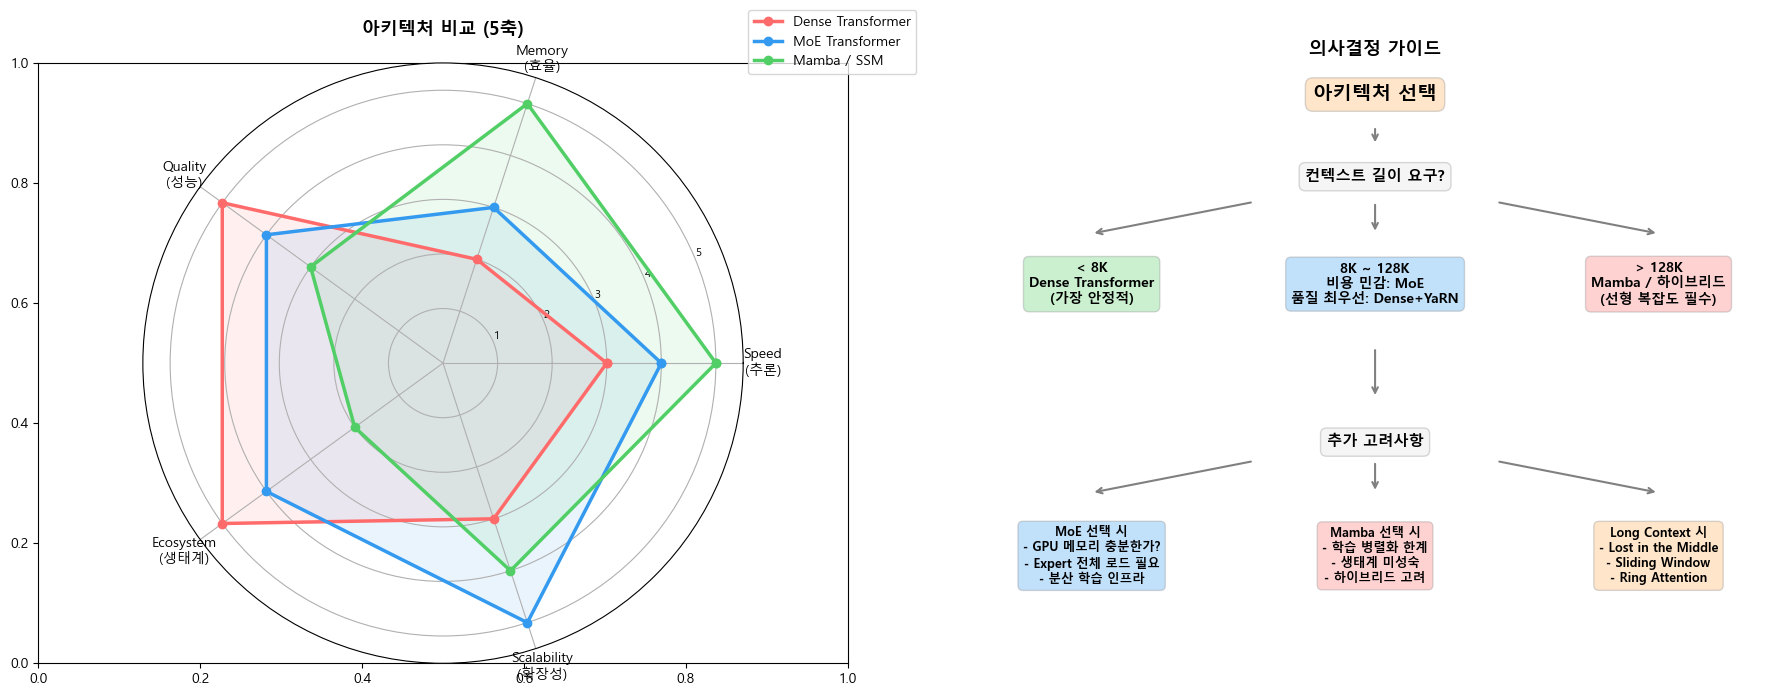

아키텍처별 점수 요약:
아키텍처                 Speed    Memory   Quality   Ecosystem  Scalability 총합
---------------------------------------------------------------------------
Dense Transformer    3        2        5         5          3           18/25
MoE Transformer      4        3        4         4          5           20/25
Mamba / SSM          5        5        3         2          4           19/25


In [11]:
# === 아키텍처 비교 Radar Chart + Decision Summary ===

fig, axes = plt.subplots(1, 2, figsize=(18, 7),
                         subplot_kw={'projection': 'polar'} if False else {})

# --- Panel 1: Radar Chart ---
ax_radar = fig.add_subplot(121, projection='polar')

categories = ['Speed\n(추론)', 'Memory\n(효율)', 'Quality\n(성능)', 'Ecosystem\n(생태계)', 'Scalability\n(확장성)']
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]  # 닫기

# 각 아키텍처 점수 (1~5)
architectures = {
    'Dense Transformer': [3, 2, 5, 5, 3],
    'MoE Transformer':   [4, 3, 4, 4, 5],
    'Mamba / SSM':       [5, 5, 3, 2, 4],
}
colors_radar = ['#ff6b6b', '#339af0', '#51cf66']

for (name, scores), color in zip(architectures.items(), colors_radar):
    scores_closed = scores + scores[:1]
    ax_radar.plot(angles, scores_closed, 'o-', linewidth=2.5, label=name, color=color, markersize=6)
    ax_radar.fill(angles, scores_closed, alpha=0.1, color=color)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=10)
ax_radar.set_ylim(0, 5.5)
ax_radar.set_yticks([1, 2, 3, 4, 5])
ax_radar.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax_radar.set_title('아키텍처 비교 (5축)', fontsize=13, fontweight='bold', pad=20)

# --- Panel 2: Decision Tree (텍스트 기반) ---
axes[1].axis('off')

# 의사결정 트리를 텍스트 박스로 표현
decision_data = [
    (0.5, 0.95, '아키텍처 선택', '#ffa94d', 14),
    (0.5, 0.82, '컨텍스트 길이 요구?', '#e0e0e0', 11),
    (0.15, 0.65, '< 8K\nDense Transformer\n(가장 안정적)', '#51cf66', 10),
    (0.5, 0.65, '8K ~ 128K\n비용 민감: MoE\n품질 최우선: Dense+YaRN', '#339af0', 10),
    (0.85, 0.65, '> 128K\nMamba / 하이브리드\n(선형 복잡도 필수)', '#ff6b6b', 10),
    (0.5, 0.40, '추가 고려사항', '#e0e0e0', 11),
    (0.15, 0.22, 'MoE 선택 시\n- GPU 메모리 충분한가?\n- Expert 전체 로드 필요\n- 분산 학습 인프라', '#339af0', 9),
    (0.5, 0.22, 'Mamba 선택 시\n- 학습 병렬화 한계\n- 생태계 미성숙\n- 하이브리드 고려', '#ff6b6b', 9),
    (0.85, 0.22, 'Long Context 시\n- Lost in the Middle\n- Sliding Window\n- Ring Attention', '#ffa94d', 9),
]

for x, y, text, color, fontsize in decision_data:
    axes[1].text(x, y, text, ha='center', va='center', fontsize=fontsize,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.3, edgecolor='gray'))

# 연결선
arrows = [
    (0.5, 0.90, 0.5, 0.87),
    (0.35, 0.78, 0.15, 0.73),
    (0.5, 0.78, 0.5, 0.73),
    (0.65, 0.78, 0.85, 0.73),
    (0.5, 0.55, 0.5, 0.47),
    (0.35, 0.37, 0.15, 0.32),
    (0.5, 0.37, 0.5, 0.32),
    (0.65, 0.37, 0.85, 0.32),
]
for x1, y1, x2, y2 in arrows:
    axes[1].annotate('', xy=(x2, y2), xytext=(x1, y1),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0.05, 1.0)
axes[1].set_title('의사결정 가이드', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("아키텍처별 점수 요약:")
print(f"{'아키텍처':<20} {'Speed':<8} {'Memory':<8} {'Quality':<9} {'Ecosystem':<10} {'Scalability':<11} {'총합'}")
print("-" * 75)
for name, scores in architectures.items():
    print(f"{name:<20} {scores[0]:<8} {scores[1]:<8} {scores[2]:<9} {scores[3]:<10} {scores[4]:<11} {sum(scores)}/25")

---
## 7. 핵심 정리

| 개념 | 핵심 |
|------|------|
| **Transformer O(n^2)** | 시퀀스 길이의 제곱에 비례하는 연산/메모리 -- 물리적 한계가 아닌 설계 선택 |
| **MoE** | 입력마다 일부 Expert만 활성화 -> 파라미터 대비 연산 3~5x 절약 |
| **Load Balancing** | Expert 간 균등 분배를 위한 Auxiliary Loss 필수 |
| **Mamba / SSM** | 선형 복잡도 O(n), Selective Scan으로 동적 기억/망각 |
| **RoPE** | 회전 행렬 기반 상대 위치 인코딩, 외삽에 약함 |
| **YaRN** | RoPE 확장, NTK-aware 보간으로 2~8배 컨텍스트 확장 |
| **ALiBi** | Attention에 선형 편향 추가, 외삽에 강함 |
| **Lost in the Middle** | 긴 문맥의 중간 정보를 놓치는 현상 |

### 핵심 원칙

> **Transformer는 정답이 아니라 현재의 최선이다.**  
> MoE는 "모든 뉴런이 매번 필요한가?"를 의심했고,  
> Mamba는 "Attention이 유일한 방법인가?"를 의심했다.  
> 다음 돌파구는 항상 **당연한 것을 의심하는 데서** 나온다.

### 다음 단계: Phase 9-02

이론에서 실전으로 -- 실제 모델에서 MoE 라우팅을 분석하고, Long Context 성능을 측정한다.

In [12]:
# === Phase 9-1 체크포인트 ===

checkpoints = [
    ("MoE의 Router -> Expert 선택 -> 가중 합산 흐름을 설명할 수 있는가", ""),
    ("Load Balancing Loss가 왜 필요한지 설명할 수 있는가", ""),
    ("Mamba의 Selective SSM이 기존 SSM과 다른 점을 말할 수 있는가", ""),
    ("Transformer O(n^2) vs Mamba O(n) 복잡도 차이의 실전 영향을 이해하는가", ""),
    ("RoPE, YaRN, ALiBi의 핵심 차이와 각각의 적합 상황을 설명할 수 있는가", ""),
    ("Lost in the Middle 문제가 무엇이며 왜 발생하는지 아는가", ""),
    ("주어진 요구사항에 맞는 아키텍처를 선택할 수 있는가", ""),
]

print("=" * 70)
print("Phase 9-1 체크포인트: 최신 아키텍처 이해 (MoE, Mamba, Long Context)")
print("=" * 70)

for i, (question, _) in enumerate(checkpoints, 1):
    print(f"\n  [{i}] {question}")

print("\n" + "=" * 70)
print(f"완료 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("\n핵심 질문:")
print("  현재 당신이 '당연하다'고 생각하는 아키텍처 가정은 무엇인가?")
print("  그 가정은 물리적 한계인가, 사회적 관성인가?")

Phase 9-1 체크포인트: 최신 아키텍처 이해 (MoE, Mamba, Long Context)

  [1] MoE의 Router -> Expert 선택 -> 가중 합산 흐름을 설명할 수 있는가

  [2] Load Balancing Loss가 왜 필요한지 설명할 수 있는가

  [3] Mamba의 Selective SSM이 기존 SSM과 다른 점을 말할 수 있는가

  [4] Transformer O(n^2) vs Mamba O(n) 복잡도 차이의 실전 영향을 이해하는가

  [5] RoPE, YaRN, ALiBi의 핵심 차이와 각각의 적합 상황을 설명할 수 있는가

  [6] Lost in the Middle 문제가 무엇이며 왜 발생하는지 아는가

  [7] 주어진 요구사항에 맞는 아키텍처를 선택할 수 있는가

완료 시각: 2026-03-20 12:07

핵심 질문:
  현재 당신이 '당연하다'고 생각하는 아키텍처 가정은 무엇인가?
  그 가정은 물리적 한계인가, 사회적 관성인가?
